# Module 01 — NumPy Foundations

*Measuring 150 flowers, the fast way.*

In 1936, botanist Edgar Anderson measured the sepals and petals of 150 iris flowers from 3 species. We'll use his data to learn **NumPy** — the array library underneath all of scientific Python.

Think of the data as a matrix, just like a gene expression matrix:

- **rows** = individuals (flowers ↔ samples)
- **columns** = measurements (petal length ↔ genes)

**How to use this notebook:** run each cell in order with `Shift+Enter`, and *predict the output before you run it*.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# One consistent, colorblind-safe look for every plot in this course
sns.set_theme(style="whitegrid", palette="colorblind")

## 1. Load the data from HuggingFace

[HuggingFace](https://huggingface.co/datasets) hosts thousands of datasets. `load_dataset` downloads one and caches it locally (the download only happens the first time).

In [2]:
from datasets import load_dataset

iris = load_dataset("scikit-learn/iris", split="train")
df = iris.to_pandas()   # a table view — we'll properly meet pandas in Module 02
df.head()

/Users/hari/repos/learning/scikit/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating train split:   0%|          | 0/150 [00:00<?, ? examples/s]

Generating train split: 100%|██████████| 150/150 [00:00<00:00, 11235.75 examples/s]

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 2. From table to array

For this module we pull the numbers out into a NumPy **array** — a pure grid of numbers.

- `shape` tells you the dimensions: `(150, 4)` = 150 flowers × 4 measurements
- `dtype` tells you the type of *every* element (unlike a Python list, an array is homogeneous — that's what makes it fast)

In [3]:
feature_names = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
X = df[feature_names].to_numpy()          # the 150 x 4 measurement matrix
species = df["Species"].to_numpy()        # one label per flower

print("shape:", X.shape)
print("dtype:", X.dtype)
print("first flower:", X[0], "->", species[0])

shape: (150, 4)
dtype: float64
first flower: [5.1 3.5 1.4 0.2] -> Iris-setosa


## 3. Why bother? Vectorization

NumPy does math on **the whole array at once**, in optimized C code, instead of looping in Python. On 150 flowers you won't feel it — so let's simulate something bigger: expression levels for the ~20,000 genes in a human genome, and time both approaches.

In [4]:
rng = np.random.default_rng(seed=42)
expression = rng.normal(loc=100, scale=20, size=20_000)   # fake expression for 20k genes

# the Python way: loop over every value
%timeit -n 10 sum(expression) / len(expression)

# the NumPy way: one vectorized call
%timeit -n 10 expression.mean()

663 μs ± 119 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
The slowest run took 4.47 times longer than the fastest. This could mean that an intermediate result is being cached.
4.65 μs ± 3.73 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


NumPy is typically **hundreds of times faster**. On a real single-cell RNA-seq matrix (thousands of cells × 20k genes) this is the difference between seconds and hours.

> **The core habit:** don't loop over data — describe the operation on the whole array.

## 4. Indexing and slicing

Same square-bracket syntax as lists, extended to two dimensions: `X[row, column]`.

In [5]:
print("flower 0, all 4 measurements:  ", X[0])        # one row
print("petal length of flower 0:       ", X[0, 2])     # one value
print("petal lengths of first 5 flowers:", X[:5, 2])   # slice rows, fix column

petal_length = X[:, 2]     # ':' means 'everything' -> the whole column
petal_width  = X[:, 3]
print("all 150 petal lengths, shape:", petal_length.shape)

flower 0, all 4 measurements:   [5.1 3.5 1.4 0.2]
petal length of flower 0:        1.4
petal lengths of first 5 flowers: [1.4 1.4 1.3 1.5 1.4]
all 150 petal lengths, shape: (150,)


## 5. Boolean masking — filtering, the array way

Comparing an array to a value gives an array of `True`/`False`. Using that mask as an index keeps only the `True` rows. This is *the* filtering idiom of scientific Python — you'll use it in pandas, scikit-learn, and scanpy.

In [6]:
is_setosa = species == "Iris-setosa"
print("mask (first 5):", is_setosa[:5])
print("number of setosa flowers:", is_setosa.sum())     # True counts as 1

setosa_petals = petal_length[is_setosa]
print("mean setosa petal length:", setosa_petals.mean().round(2), "cm")

mask (first 5): [ True  True  True  True  True]
number of setosa flowers: 50
mean setosa petal length: 1.46 cm


In [7]:
# Combine the idea with a loop over species names:
for name in np.unique(species):
    mask = species == name
    print(f"{name:18s} mean petal length: {petal_length[mask].mean():.2f} cm")

Iris-setosa        mean petal length: 1.46 cm
Iris-versicolor    mean petal length: 4.26 cm
Iris-virginica     mean petal length: 5.55 cm


Setosa petals are ~1.5 cm, virginica ~5.5 cm — nearly 4× longer. Measurements really do carry species identity. Let's *see* it.

## 6. First plot: distributions by species

A histogram shows the **distribution** of a measurement — how many flowers fall in each range.

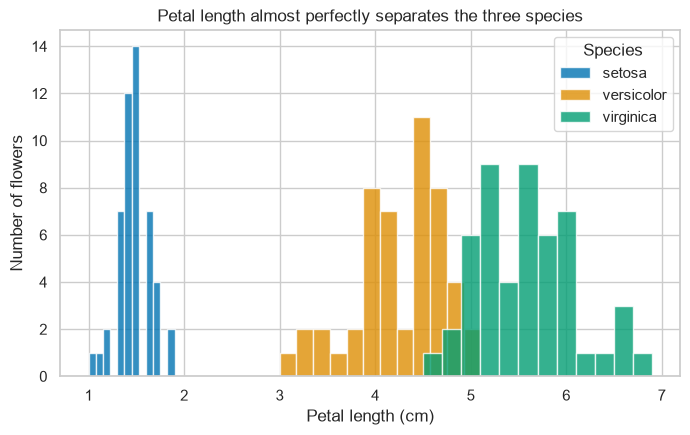

In [8]:
palette = sns.color_palette("colorblind")
SPECIES_COLORS = {                       # fixed color per species, used in every plot
    "Iris-setosa": palette[0],
    "Iris-versicolor": palette[1],
    "Iris-virginica": palette[2],
}

fig, ax = plt.subplots(figsize=(8, 4.5))
for name, color in SPECIES_COLORS.items():
    ax.hist(petal_length[species == name], bins=12, alpha=0.8,
            color=color, label=name.replace("Iris-", ""))
ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Number of flowers")
ax.set_title("Petal length almost perfectly separates the three species")
ax.legend(title="Species")
plt.show()

Setosa is completely separate; versicolor and virginica overlap a little. One measurement gets you most of the way to a species ID.

## 7. Vectorized math — new measurements from old

Arithmetic on arrays works element-by-element. One expression computes a value for all 150 flowers — no loop.

In [9]:
petal_area = petal_length * petal_width      # 150 multiplications at once
print("first 5 petal areas (cm^2):", petal_area[:5].round(2))

# argmax returns the INDEX of the largest value -> use it to look up the flower
champion = petal_area.argmax()
print(f"\nBiggest petals: flower #{champion} ({species[champion]}), "
      f"{petal_length[champion]} x {petal_width[champion]} cm")

first 5 petal areas (cm^2): [0.28 0.28 0.26 0.3  0.28]

Biggest petals: flower #118 (Iris-virginica), 6.9 x 2.3 cm


## 8. Broadcasting and z-scores

`X - X.mean(axis=0)` subtracts a 4-number row from a 150×4 matrix. NumPy "broadcasts" the small array across the big one — no loop needed.

The result here is the **z-score**: *how many standard deviations is this flower from the average?* This is the same standardization applied to gene expression data before clustering, and scikit-learn will do it for us later (`StandardScaler`).

`axis=0` means "compute down the columns" (one result per measurement); `axis=1` would go across rows (one result per flower).

In [10]:
col_means = X.mean(axis=0)    # 4 values: average of each measurement
col_stds  = X.std(axis=0)     # 4 values: spread of each measurement
print("column means:", col_means.round(2))

X_z = (X - col_means) / col_stds     # broadcasting: (150,4) minus (4,) works!
print("z-scored means (~0):", X_z.mean(axis=0).round(2))
print("z-scored stds  (~1):", X_z.std(axis=0).round(2))
print("flower 0 in z-scores:", X_z[0].round(2))

column means: [5.84 3.05 3.76 1.2 ]
z-scored means (~0): [-0. -0.  0. -0.]
z-scored stds  (~1): [1. 1. 1. 1.]
flower 0 in z-scores: [-0.9   1.03 -1.34 -1.31]


## 9. Two measurements at once: the scatter plot

If one measurement almost separates species, two should do even better. Each point is one flower; color = species.

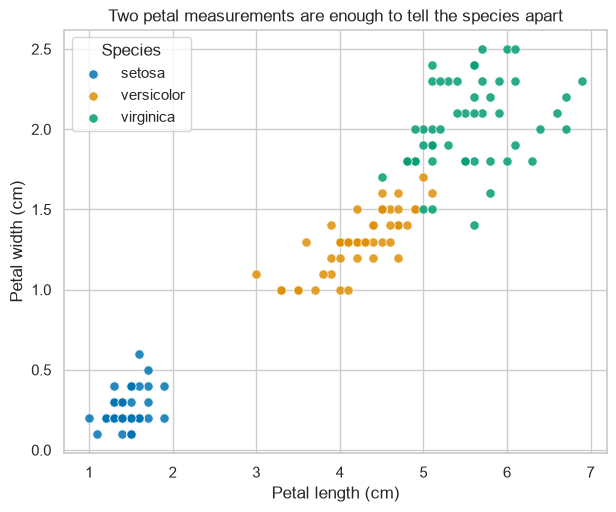

In [11]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for name, color in SPECIES_COLORS.items():
    mask = species == name
    ax.scatter(petal_length[mask], petal_width[mask], s=45, alpha=0.85,
               color=color, edgecolor="white", linewidth=0.6,
               label=name.replace("Iris-", ""))
ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Petal width (cm)")
ax.set_title("Two petal measurements are enough to tell the species apart")
ax.legend(title="Species")
plt.show()

Three clean clouds. When a machine learning model "classifies" iris species, all it's really doing is drawing boundaries between these clouds — which you can now basically do by eye.

## Recap

| Idea | Code |
|---|---|
| The data matrix | `X.shape` → `(150, 4)` |
| Grab a column | `X[:, 2]` |
| Filter by condition | `X[species == "Iris-setosa"]` |
| Math on everything at once | `petal_length * petal_width` |
| Summaries per column | `X.mean(axis=0)` |
| Standardize | `(X - X.mean(axis=0)) / X.std(axis=0)` |
| Find the extreme | `petal_area.argmax()` |

Now head to [exercises.md](exercises.md) — the last one has you build a tiny classifier by hand.